# Module 05 — Introduction to Machine Learning
### AI-ML Course | সম্পূর্ণ নোট (বাংলায়)

---

## 📌 এই Module-এ যা যা শিখব

| Topic | বিষয় |
|---|---|
| 5-1 | Introduction — ML কী এবং কেন শিখব |
| 5-2 | What is Machine Learning |
| 5-3 | Types of ML & Real-Life Use Cases |
| 5-4 | ML Essentials — Features, Labels, Training, Testing, Generalization |
| 5-5 | ML Pipeline |
| 5-6 | ML Pipeline-এর Practical Example |
| 5-7 | Common ML Applications & Challenges |
| 5-8 | Module Wrap-Up |


---

## 5-1 & 5-2 — What is Machine Learning?

### সহজ ভাষায় ML কী?

**Machine Learning (ML)** হলো এমন একটি পদ্ধতি যেখানে computer-কে explicitly (সরাসরি) rules বলে দেওয়া হয় না, বরং **data থেকে pattern শিখতে** দেওয়া হয়।

> সহজ উদাহরণ: YouTube কীভাবে জানে তুমি কোন video দেখতে চাও? তোমার past watch history দেখে সে **pattern** শিখে নেয় — এটাই ML।

---

### Traditional Programming vs. Machine Learning

| Traditional Programming | Machine Learning |
|---|---|
| তুমি Rules লিখে দাও | Model নিজেই Rules শিখে নেয় |
| Data + Rules → Answers | Data + Answers → Rules |
| Rigid, manual | Flexible, data-driven |

**Real-Life Examples:**
- **Gmail Spam Filter** → Spam mail চেনে
- **Netflix Suggestions** → পছন্দের show recommend করে
- **Face Recognition** → ছবি থেকে মুখ চেনে
- **Fraud Detection** → সন্দেহজনক transaction ধরে
- **Voice Assistants** (Alexa, Google Home) → কথা বুঝতে পারে
- **Autonomous Vehicles** → নিজে নিজে গাড়ি চালায়

In [1]:
# Traditional Programming vs. Machine Learning — concept demo


# Traditional approach: rules are hardcoded manually
def is_spam_traditional(email_text):
    spam_keywords = ["win a million", "free money", "click here now"]
    for keyword in spam_keywords:
        if keyword in email_text.lower():
            return "SPAM"
    return "NOT SPAM"


# ML approach: model learns patterns from labeled data
# (Below is a simplified illustration, not a real ML model)
def is_spam_ml_concept(email_text, learned_patterns):
    """
    In ML, 'learned_patterns' comes from training on thousands of
    labeled spam/not-spam examples. The model figures out the rules itself.
    """
    score = sum(1 for pattern in learned_patterns if pattern in email_text.lower())
    return "SPAM" if score > 2 else "NOT SPAM"


test_email = "Congratulations! You win a million dollars! Click here now to claim!"
print("Traditional:", is_spam_traditional(test_email))

# Simulated learned patterns
patterns = ["win", "million", "click here", "free", "congratulations", "claim"]

print("ML approach:", is_spam_ml_concept(test_email, patterns))

Traditional: SPAM
ML approach: SPAM


উপরের code-এ দেখো:
- **Traditional approach**: আমরা নিজেরাই `spam_keywords` list বানিয়ে দিয়েছি — rule manually লেখা।
- **ML approach**: `learned_patterns` কিন্তু training data থেকে model নিজেই বের করে নেয় — rule আপনাআপনি শেখে।

Real ML-এ `learned_patterns` আসে হাজার হাজার email দেখে training-এর মাধ্যমে, আমরা manually দিই না।

---

## 5-3 — Types of Machine Learning

ML-কে মূলত **৩টি বড় ভাগে** ভাগ করা হয়:

| Type | Data | কীভাবে শেখে | Real Example |
|---|---|---|---|
| **Supervised Learning** | Labeled data | সঠিক উত্তর দেখে শেখে | Image Classification, Spam Detection |
| **Unsupervised Learning** | Unlabeled data | নিজেই pattern খোঁজে | Customer Segmentation, Clustering |
| **Reinforcement Learning** | Reward/Penalty | Trial & error থেকে শেখে | Game playing AI, Robot walking |

---

### Supervised Learning
- **সহজ ব্যাখ্যা**: Teacher যেমন student-কে প্রশ্ন ও উত্তর সহ পড়ায়, তেমনি model-কে **labeled examples** দিয়ে train করা হয়।
- **উদাহরণ**: রোগীর Gender ও Age দেখে সে sick নাকি healthy — এটা model শিখে নেয় আগের labeled data থেকে।

### Unsupervised Learning
- **সহজ ব্যাখ্যা**: কোনো label নেই। Model নিজেই data-র মধ্যে groups বা patterns খুঁজে বের করে।
- **উদাহরণ**: রোগীর Gender ও Age আছে, কিন্তু healthy/sick label নেই। Model age/gender দেখে নিজেই groups তৈরি করে।

### Reinforcement Learning
- **সহজ ব্যাখ্যা**: কুকুর train করার মতো — সঠিক কাজ করলে reward, ভুল করলে penalty। বারবার চেষ্টা করে শেখে।
- **উদাহরণ**: AI agent একটি ফলের ছবি দেখে ভুল বলে — feedback পায় "Wrong! It's an apple" — পরের বার ঠিক বলে।

In [2]:
# Supervised vs. Unsupervised Learning — data example
import pandas as pd

# Supervised Learning data — label (sick/healthy) আছে
supervised_data = pd.DataFrame({
    'Gender': ['M', 'M', 'F', 'M', 'F', 'M', 'M'],
    'Age':    [48,  67,  53,  49,  32,  34,  21],
    'Label':  ['sick', 'sick', 'healthy', 'sick', 'healthy', 'healthy', 'healthy']
})

# Unsupervised Learning data — কোনো label নেই
unsupervised_data = pd.DataFrame({
    'Gender': ['M', 'M', 'F', 'M', 'F', 'M'],
    'Age':    [48,  67,  53,  49,  34,  21]
})

print("=== Supervised Learning Data (labeled) ===")
print(supervised_data)
print()
print("=== Unsupervised Learning Data (no label) ===")
print(unsupervised_data)

=== Supervised Learning Data (labeled) ===
  Gender  Age    Label
0      M   48     sick
1      M   67     sick
2      F   53  healthy
3      M   49     sick
4      F   32  healthy
5      M   34  healthy
6      M   21  healthy

=== Unsupervised Learning Data (no label) ===
  Gender  Age
0      M   48
1      M   67
2      F   53
3      M   49
4      F   34
5      M   21


উপরে দেখো:
- **Supervised data**: `Label` column আছে — model জানে প্রতিটি row-এর সঠিক উত্তর কী।
- **Unsupervised data**: `Label` column নেই — model নিজেই বুঝবে কে কার কাছাকাছি (যেমন বয়স্করা একদল, তরুণরা আরেকদল)।

> **⚠️ Interview Tip**: Supervised-এ **loss function** দিয়ে error measure করা হয় (কারণ সঠিক উত্তর জানা আছে)। Unsupervised-এ কোনো ground truth label নেই, তাই সরাসরি accuracy measure করা যায় না।

---

## 5-4 — Machine Learning Essentials

ML বুঝতে হলে এই ৫টি concept একদম clear হতে হবে:

### 1. Features
- **কী**: Input data — model যে তথ্যগুলো দিয়ে শেখে।
- **উদাহরণ**: আমের রং, আকার, ওজন, texture।
- **Good features**: Sweet level of fruit, size of a pet, words in an email.
- **Bad features**: Background color in a photo, brand of fruit peeler — irrelevant, model-কে confuse করে।

### 2. Labels
- **কী**: Output — সঠিক উত্তর যেটা model predict করতে শেখে।
- **উদাহরণ**: Image → "Mango" বা "Not Mango"; Loan application → "Approve" বা "Reject"।
- Labels **categories** (classification) বা **numbers** (regression) হতে পারে।

### 3. Training
- **কী**: Model-কে labeled data দেখিয়ে শেখানোর process।
- Features ও Labels-এর মধ্যে **pattern** খোঁজে। Error কমাতে parameters adjust করে।

### 4. Testing
- **কী**: Training শেষে নতুন (unseen) data দিয়ে model-কে পরীক্ষা করা।
- Test data-তে **কোনো label দেওয়া হয় না** — model নিজেই predict করে।

### 5. Generalization
- **কী**: Unseen (নতুন) data-তেও model কতটা ভালো কাজ করে।
- **Good generalization**: নতুন examples সঠিকভাবে predict করতে পারে।
- **Poor generalization**: Training data মুখস্থ করেছে, নতুন data-তে fail করে।

In [3]:
# Features এবং Labels clearly identify করা
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# Dataset: Loan Approval — Real-life ML Essentials example
data = {
    'Income':       [50000, 30000, 80000, 20000, 60000, 45000, 90000, 15000],
    'Credit_Score': [750, 500, 800, 450, 700, 620, 820, 400],
    'Employed':     [1, 0, 1, 0, 1, 1, 1, 0],  # 1=Yes, 0=No
    'Loan_Amount':  [200000, 100000, 300000, 80000, 150000, 120000, 400000, 60000],
    'Approved':     [1, 0, 1, 0, 1, 1, 1, 0]   # Label: 1=Approved, 0=Rejected
}

df = pd.DataFrame(data)
print("=== Dataset ===")
print(df)
print()

# Step 1: Features (X) and Label (y) আলাদা করা
X = df.drop('Approved', axis=1)  # Features
y = df['Approved']               # Label

print("=== Features (X) ===")
print(X)

print("\n=== Label (y) ===")
print(y)

=== Dataset ===
   Income  Credit_Score  Employed  Loan_Amount  Approved
0   50000           750         1       200000         1
1   30000           500         0       100000         0
2   80000           800         1       300000         1
3   20000           450         0        80000         0
4   60000           700         1       150000         1
5   45000           620         1       120000         1
6   90000           820         1       400000         1
7   15000           400         0        60000         0

=== Features (X) ===
   Income  Credit_Score  Employed  Loan_Amount
0   50000           750         1       200000
1   30000           500         0       100000
2   80000           800         1       300000
3   20000           450         0        80000
4   60000           700         1       150000
5   45000           620         1       120000
6   90000           820         1       400000
7   15000           400         0        60000

=== Label (y) ===
0    1


In [4]:
# Step 2: Train-Test Split — Training ও Testing data আলাদা করা
# test_size=0.25 মানে 25% test-এ রাখা, 75% training-এ
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)
# Here X_train is train data adn X_test is test data, and all of them are randomly selected from Features.
# And y_train is train data, and y_test is test data, and they are also randomly selected from Labels.


print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")


# Step 3: Model Training — model loan approval pattern শিখবে
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
print("\nModel training complete!")


# Step 4: Testing — unseen data-তে predict করা
y_pred = model.predict(X_test)
print(f"\nPredictions on test data: {y_pred}")
print(f"Actual labels:            {y_test.values}")


# Step 5: Generalization check — accuracy দেখা
train_accuracy = accuracy_score(y_train, model.predict(X_train))
test_accuracy  = accuracy_score(y_test, y_pred)
print(f"\nTraining Accuracy: {train_accuracy:.2f}")
print(f"Testing Accuracy:  {test_accuracy:.2f}")

Training samples: 6
Testing samples:  2

Model training complete!

Predictions on test data: [0 1]
Actual labels:            [0 1]

Training Accuracy: 1.00
Testing Accuracy:  1.00


উপরের code-এ একটি complete ML workflow দেখানো হয়েছে:

- **`X`** = Features (Income, Credit Score, Employed, Loan Amount) — model এগুলো দেখে শেখে।
- **`y`** = Label (Approved/Rejected) — model এটাই predict করতে শেখে।
- **`train_test_split`** দিয়ে data ভাগ করা হয়েছে — training-এর সময় model test data দেখতে পায় না।
- **Training accuracy** বেশি কিন্তু **testing accuracy** কম হলে বুঝতে হবে model **overfitting** করেছে — ভালো generalization হয়নি।

> **⚠️ Interview Tip**: `train_test_split`-এ `random_state` দেওয়া হয় যাতে প্রতিবার একই split পাওয়া যায় (reproducibility)। না দিলে প্রতিবার আলাদা result আসবে।

---

## 5-5 & 5-6 — ML Pipeline

**ML Pipeline** হলো raw data থেকে prediction পর্যন্ত পৌঁছানোর step-by-step workflow।

```
Data Collection → Preprocessing → Training → Evaluation
```

### Step 1: Data Collection
- সবকিছুর শুরু — real world থেকে examples collect করা।
- **উদাহরণ**: রাইপ/আনরাইপ আমের ছবি, spam/non-spam email, বাড়ির বিক্রয় data।
- **Golden Rule**: "Garbage in, garbage out" — খারাপ data দিলে খারাপ model বের হবে।
- Biased বা incomplete data → biased predictions।

### Step 2: Preprocessing
- Raw data প্রায় সবসময়ই messy থাকে।
- **ML project-এর ৬০-৮০% সময় এই step-এ যায়।**
  - Duplicate entries remove করা
  - Missing values fill করা বা remove করা
  - Format standardize করা
  - Outlier remove করা

### Step 3: Training
- Cleaned data → ML algorithm-এ feed করা হয়।
- Model **pattern recognize** করে ও **parameters adjust** করে error কমায়।

### Step 4: Evaluation
- Training শেষে আলাদা **test data** দিয়ে model পরীক্ষা করা হয়।
- **Generalization** চেক করা — model কি শুধু মুখস্থ করেছে, নাকি সত্যিই শিখেছে?

In [5]:
# Complete ML Pipeline — ধাপে ধাপে একটি উদাহরণ
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


# ========== STEP 1: Data Collection ==========
# Here we create sample data manually.
# In real projects, this comes from CSV files, databases, or APIs.
np.random.seed(42)
n = 200


data = pd.DataFrame({
    'Color':    np.random.choice([0, 1, 2], n),   # 0=Green, 1=Yellow, 2=Orange
    'Weight':   np.random.uniform(100, 400, n),
    'Softness': np.random.uniform(0, 10, n),
    'Ripe':     np.random.choice([0, 1], n)        # 0=Unripe, 1=Ripe
})


print("STEP 1 — Data Collection")
print(f"Total samples: {len(data)}")
print(data.head())

STEP 1 — Data Collection
Total samples: 200
   Color      Weight  Softness  Ripe
0      2  221.150851  1.753303     0
1      0  119.467674  0.171611     1
2      2  176.174624  7.633644     0
3      2  174.062819  8.069130     1
4      0  308.891282  3.463043     0


In [6]:
# ========== STEP 2: Preprocessing ==========

# 2a: Artificially introduce some missing values to practice handling
data.loc[5, 'Weight'] = np.nan
data.loc[12, 'Softness'] = np.nan


# Now let's check the missing values'
print("STEP 2 — Preprocessing")
print("Manually checking sample missing values:")
print(data.iloc[5, 1])
print(data.iloc[12, 2])
print()


# Check missing values

print("Total missing values before cleaning:")
print(data.isnull().sum())


# 2b: Fill missing values with column mean
data['Weight'].fillna(data['Weight'].mean(), inplace=True)
data['Softness'].fillna(data['Softness'].mean(), inplace=True)


print("\nTotal missing values after cleaning:")
print(data.isnull().sum())

STEP 2 — Preprocessing
Manually checking sample missing values:
nan
nan

Total missing values before cleaning:
Color       0
Weight      1
Softness    1
Ripe        0
dtype: int64

Total missing values after cleaning:
Color       0
Weight      0
Softness    0
Ripe        0
dtype: int64


In [7]:
# ========== STEP 3: Training ==========

# Features and label split
X = data.drop('Ripe', axis=1)
y = data['Ripe']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling: StandardScaler makes all features on the same scale
# This is important so that Weight (100-400) doesn't dominate Softness (0-10)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on training data
X_test_scaled  = scaler.transform(X_test)         # only transform on test data (no fit!)

# Train the model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

print("STEP 3 — Training complete!")
print(f"Model trained on {len(X_train)} samples.")

STEP 3 — Training complete!
Model trained on 160 samples.


In [8]:
# ========== STEP 4: Evaluation ==========

y_pred = model.predict(X_test_scaled)

print("STEP 4 — Evaluation")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred, target_names=['Unripe', 'Ripe'], zero_division=0))

STEP 4 — Evaluation
Test Accuracy: 0.53

Detailed Report:
              precision    recall  f1-score   support

      Unripe       0.52      0.55      0.54        20
        Ripe       0.53      0.50      0.51        20

    accuracy                           0.53        40
   macro avg       0.53      0.53      0.52        40
weighted avg       0.53      0.53      0.52        40



উপরের ৪টি code block-এ একটি complete ML pipeline দেখানো হয়েছে:

- **Step 1**: Data তৈরি/collect করা (real project-এ CSV বা database থেকে আসে)।
- **Step 2**: Missing values fill করা — `fillna(mean())` দিয়ে গড় দিয়ে fill করা হয়েছে।
- **Step 3**: `StandardScaler` দিয়ে features scale করা হয়েছে, তারপর `LogisticRegression` model train করা হয়েছে।
  - **⚠️ গুরুত্বপূর্ণ**: Scaler-এর `fit_transform` শুধু training data-তে, test data-তে শুধু `transform` — কারণ test data দেখে scaler train করলে **data leakage** হবে।
- **Step 4**: `classification_report` দিয়ে precision, recall, f1-score সব একসাথে দেখা যায়।

> **⚠️ Common Beginner Mistakes:**
> - Preprocessing skip করা → confused model
> - Biased data collect করা → biased predictions
> - শুধু training accuracy দেখা, test accuracy না দেখা
> - পর্যাপ্ত data না নেওয়া (10টা ছবি দিয়ে ML হয় না)

---

## 5-7 — Common ML Applications & Challenges

### ML Applications — চারদিকে ML কোথায় কোথায় আছে

| Application | কীভাবে কাজ করে |
|---|---|
| **Next Word Prediction** | আগের words দেখে পরের word predict করে |
| **Traffic Prediction** (Google Maps) | লক্ষ লক্ষ trip data থেকে jam predict করে |
| **Recommendation Systems** (Netflix, YouTube, Amazon, Spotify) | তোমার history দেখে পছন্দ বোঝে |
| **Email Spam Filtering** | Spam pattern শিখে filter করে |
| **Fraud Detection** | Unusual transaction pattern ধরে |
| **Agriculture Drones** | Leaf color দেখে plant disease detect করে |
| **Smart Shelf Monitoring** | Camera দিয়ে stock count করে |
| **Auto Camera Adjustment** | Scene বুঝে brightness/sharpness adjust করে |

---

### Challenge 1: Bias — যখন Data Fair না হয়

Training data biased হলে model unfair pattern শেখে।

- **Biased Hiring Tool**: Male employee data বেশি থাকলে model male candidate prefer করে।
- **Soap Dispenser**: Darker skin tone-এর কম data → dispenser detect করতে পারে না।
- **Loan Rejection**: নির্দিষ্ট এলাকার মানুষ historically reject হলে model সেই pattern শেখে।
- **Fix**: Diverse, representative data নেওয়া এবং fairness test করা।

### Challenge 2: Overfitting — বেশি মুখস্থ করা

Model training data মুখস্থ করে ফেলে, pattern শেখে না।

- **Training accuracy**: খুব বেশি (98-100%)
- **Test accuracy**: অনেক কম (60-70%)
- **উদাহরণ**: Student practice questions মুখস্থ করেছে, real exam-এ ভিন্নভাবে ask করলে fail।
- **Fix**: More training data, Regularization, Cross-validation।

### Challenge 3: Underfitting — কম শেখা

Model too simple — important pattern ধরতে পারে না।

- **Training accuracy**: কম
- **Test accuracy**: কম
- **উদাহরণ**: শুধু bedroom count দিয়ে house price predict করা — location, size সব ignore।
- **Fix**: More complex model ব্যবহার করা, better features যোগ করা।

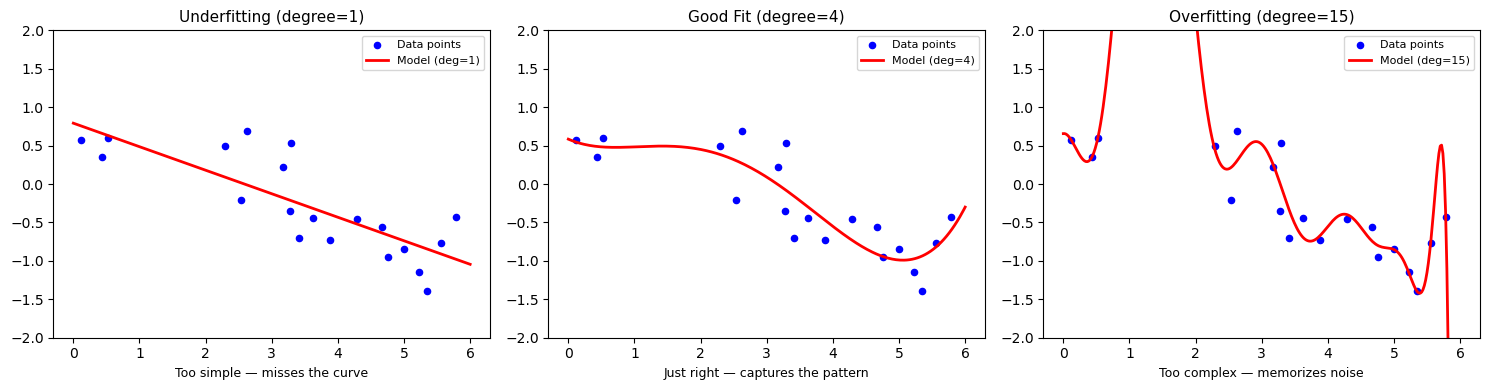

Chart saved!


In [9]:
# Overfitting vs. Underfitting — visual demo
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline


# Generate simple data: y = sin(x) + noise
np.random.seed(0)
X_data = np.sort(np.random.uniform(0, 6, 20)).reshape(-1, 1)
y_data = np.sin(X_data).ravel() + np.random.normal(0, 0.3, 20)

X_plot = np.linspace(0, 6, 300).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))


configs = [
    (1, "Underfitting (degree=1)", "Too simple — misses the curve"),
    (4, "Good Fit (degree=4)", "Just right — captures the pattern"),
    (15, "Overfitting (degree=15)", "Too complex — memorizes noise")
]


for ax, (degree, title, desc) in zip(axes, configs):
    model_poly = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model_poly.fit(X_data, y_data)
    y_plot = model_poly.predict(X_plot)

    ax.scatter(X_data, y_data, color='blue', s=20, label='Data points')
    ax.plot(X_plot, y_plot, color='red', lw=2, label=f'Model (deg={degree})')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(desc, fontsize=9)
    ax.legend(fontsize=8)
    ax.set_ylim(-2, 2)

plt.tight_layout()
plt.savefig('fitting_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print("Chart saved!")

উপরের chart-এ তিনটি model দেখানো হয়েছে:

- **বাম দিক (Underfitting)**: Degree=1 (straight line) — data-র curve ধরতে পারছে না। Training ও test accuracy দুটোই খারাপ।
- **মাঝের (Good Fit)**: Degree=4 — data-র actual pattern ভালোভাবে capture করছে। Generalization ভালো।
- **ডান দিক (Overfitting)**: Degree=15 — প্রতিটি data point-এর noise সহ মুখস্থ করে ফেলেছে। Training-এ perfect, কিন্তু নতুন data-তে ভেঙে পড়বে।

> **⚠️ Interview Tip — Bias vs. Variance Tradeoff:**
> - **Underfitting** = High Bias (model ধারণা সরল রেখেছে)
> - **Overfitting** = High Variance (model data-র সব noise মুখস্থ করেছে)
> - ভালো ML = এই দুইয়ের মাঝে balance রাখা।

In [10]:
# Bias in ML — simple demonstration
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Biased training data: mostly male employees — female data কম
biased_train = pd.DataFrame({
    'Gender': [1, 1, 1, 1, 1, 1, 0],  # 1=Male, 0=Female
    'Score':  [80, 75, 90, 85, 70, 88, 92],
    'Hired':  [1,  1,  1,  1,  0,  1,  0]   # 0=Not hired
})

# Test data: balanced — male ও female সমান
test_data = pd.DataFrame({
    'Gender': [1, 0, 1, 0],
    'Score':  [78, 85, 72, 88],
    'Hired':  [1,  1,  0,  1]   # Both genders have qualified candidates
})

X_biased = biased_train[['Gender', 'Score']]
y_biased = biased_train['Hired']

X_test = test_data[['Gender', 'Score']]
y_test = test_data['Hired']

# Train on biased data
biased_model = DecisionTreeClassifier(random_state=0)
biased_model.fit(X_biased, y_biased)

# Predictions
y_pred = biased_model.predict(X_test)

print("=== Predictions on balanced test data ===")
print(f"Predicted: {y_pred}")
print(f"Actual:    {y_test.values}")
print("\n(Notice: Biased training data can cause the model to be unfair to females)")

=== Predictions on balanced test data ===
Predicted: [1 0 0 0]
Actual:    [1 1 0 1]

(Notice: Biased training data can cause the model to be unfair to females)


উপরের code-এ দেখানো হয়েছে:

- **Training data biased**: বেশিরভাগ male employee hired। Female data মাত্র ১টি।
- **Model এই bias শিখে নেয়**: Female candidate qualified হলেও model তাকে unfairly reject করতে পারে।
- **Real-world impact**: Amazon এরকম একটি hiring tool retire করতে বাধ্য হয়েছিল কারণ এটি female candidate-দের বিরুদ্ধে biased ছিল।

> **Fix**: Diverse ও representative training data নেওয়া, fairness metrics (demographic parity, equal opportunity) দিয়ে model test করা।

---

## 5-8 — Module Wrap-Up & Quick Review

### Module 05-এ যা শিখলাম — এক নজরে

| Concept | এক লাইনে |
|---|---|
| **Machine Learning** | Data থেকে pattern শিখে decision নেয় |
| **Supervised Learning** | Labeled data দিয়ে শেখা |
| **Unsupervised Learning** | Label ছাড়া নিজেই pattern খোঁজে |
| **Reinforcement Learning** | Reward/Penalty দিয়ে trial & error-এ শেখে |
| **Features** | Input data — model যা দেখে শেখে |
| **Labels** | Output — model যা predict করে |
| **Training** | Model-কে labeled data দেখিয়ে শেখানো |
| **Testing** | Unseen data-তে model-এর পরীক্ষা |
| **Generalization** | নতুন data-তে কতটা ভালো কাজ করে |
| **Bias** | Unfair data → unfair predictions |
| **Overfitting** | Training data মুখস্থ, test-এ fail |
| **Underfitting** | Too simple model, everywhere bad |

---

### ⚡ Interview-এর জন্য গুরুত্বপূর্ণ Points

1. **Supervised vs. Unsupervised**: Supervised-এ label আছে ও loss function দিয়ে error measure করা যায়। Unsupervised-এ কোনো ground truth নেই।

2. **Overfitting চেনার উপায়**: Training accuracy >> Test accuracy। Solution: More data, Regularization (L1/L2), Dropout, Cross-validation।

3. **Underfitting চেনার উপায়**: Training ও test accuracy দুটোই কম। Solution: Complex model, better features।

4. **Data Leakage (tricky!)**: Test data-র information যদি training-এ ঢুকে যায় তাহলে artificially বেশি accuracy দেখায়। `scaler.fit_transform` কখনো test-এ করা যাবে না — শুধু `transform` করতে হবে।

5. **"Garbage in, Garbage out"**: ML-এর সবচেয়ে বড় lesson। সবচেয়ে powerful algorithm-ও খারাপ data দিলে খারাপ result দেবে।

6. **ML Pipeline-এর ৬০-৮০% সময় Preprocessing-এ যায়** — fancy algorithm নয়, ভালো data preparation-ই key।

---

### Next Up: Module 06
**Data Preprocessing & Feature Engineering** — Missing values handle করা, Categorical data encode করা, Normalization & Scaling, Outlier detection — এগুলো নিয়ে বিস্তারিত পড়ব।

---